# 🔬 Gemma 4 E4B — Jaundice Image Classification Fine-Tuning
**Folder-based dataset · Kaggle auto-download · QLoRA · GGUF export right after training**

This notebook:
1. Installs all dependencies
2. Downloads the Kaggle jaundice dataset automatically via `kagglehub`
3. Scans `jaundice/` and `normal/` folders — no CSV needed
4. Validates & preprocesses every image
5. Loads **Gemma 4 E4B** in 4-bit with LoRA via Unsloth
6. Fine-tunes with SFTTrainer
7. **Immediately exports GGUF + triggers download** (before session expires)
8. Evaluates and runs interactive inference

> **Runtime:** GPU T4 or better.  Runtime → Change runtime type → T4 GPU.

## 1 — Install Dependencies

In [1]:
%%capture
import os, re, sys

# ── Unsloth + training stack ──────────────────────────────────────────────────
if 'COLAB_' not in ''.join(os.environ.keys()):
    os.system('pip install unsloth')
else:
    import torch
    v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {
        '2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'
    }.get(v,'0.0.34')
    os.system('pip install sentencepiece protobuf "datasets==2.18.0" hf_transfer')
    os.system(
        f'pip install --no-deps unsloth_zoo bitsandbytes accelerate '
        f'{xformers} peft trl triton unsloth'
    )
    os.system('pip install --no-deps --upgrade "torchao>=0.16.0"')

# Single hub pin — never downgrade
os.system('pip install "huggingface_hub==1.5.0" --quiet')
os.system('pip install --no-deps transformers==5.5.0 "tokenizers>=0.22.0,<=0.23.0"')
os.system('pip install --no-deps --upgrade timm --quiet')

# Image / eval / viz deps  (NO audio libs)
os.system('pip install Pillow scikit-learn matplotlib seaborn kagglehub --quiet')

import torch
torch._dynamo.config.recompile_limit = 64
print('✅ All dependencies installed.')


## 2 — Global Configuration

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
#  GLOBAL CONFIGURATION — edit here only
# ══════════════════════════════════════════════════════════════════════════════

CFG = dict(
    # ── Kaggle dataset ────────────────────────────────────────────────────────
    kaggle_dataset   = 'aiolapo/jaundice-image-data',

    # ── Folder → label mapping (folder name → canonical response) ─────────────
    # The dataset has subfolders: jaundice/ and normal/
    folder_label_map = {
        'jaundice' : 'Jaundice: Yes',
        'normal'   : 'Jaundice: No',
        # add more mappings if the dataset has other folder names:
        # 'yes'    : 'Jaundice: Yes',
        # 'no'     : 'Jaundice: No',
    },
    pos_response     = 'Jaundice: Yes',
    neg_response     = 'Jaundice: No',

    # ── Image preprocessing ───────────────────────────────────────────────────
    image_size       = 448,
    augment_train    = True,

    # ── Instruction variants (randomly sampled per training sample) ───────────
    instructions     = [
        'Analyze this medical image and determine whether jaundice symptoms are visible.',
        'Check this image carefully and classify whether jaundice is present.',
        'Examine this clinical photograph and identify if jaundice signs are present.',
        'Review this medical photograph and determine if jaundice is indicated.',
        'Look at this image and answer: does the patient show signs of jaundice?',
        'Assess the image for jaundice indicators such as yellow skin or eye discoloration.',
    ],

    # ── Train / val split ─────────────────────────────────────────────────────
    val_split        = 0.10,
    seed             = 42,

    # ── Model ─────────────────────────────────────────────────────────────────
    model_name       = 'unsloth/gemma-4-E4B-it',
    max_seq_length   = 4096,
    load_in_4bit     = True,

    # ── LoRA ──────────────────────────────────────────────────────────────────
    lora_r           = 16,
    lora_alpha       = 16,
    lora_dropout     = 0.0,

    # ── SFT training ──────────────────────────────────────────────────────────
    per_device_batch = 1,             # T4 safe with vision + 4-bit
    grad_accum       = 4,
    num_epochs       = 1,
    max_steps        = -1,
    learning_rate    = 2e-4,
    weight_decay     = 0.01,
    warmup_ratio     = 0.03,
    lr_scheduler     = 'cosine',
    logging_steps    = 5,
    save_steps       = 200,
    output_dir       = '/content/outputs',

    # ── GGUF export (runs automatically right after training) ─────────────────
    gguf_dir         = '/content/jaundice_gemma4_gguf',
    gguf_method      = 'q2_k',  # because of i train free colab

    # ── LoRA save (backup alongside GGUF) ────────────────────────────────────
    lora_save_path   = '/content/jaundice_gemma4_lora',

    # ── Optional: Hugging Face Hub ────────────────────────────────────────────
    push_to_hub      = False,
    hf_repo          = 'YOUR_HF_USER/jaundice-gemma4-lora',
    hf_token         = '',
)

import os, pathlib, random
random.seed(CFG['seed'])
for d in [CFG['output_dir'], CFG['lora_save_path'], '/content/quarantine']:
    pathlib.Path(d).mkdir(parents=True, exist_ok=True)

print('✅ Configuration set.')
for k, v in CFG.items():
    print(f'   {k:25s} = {v}')


✅ Configuration set.
   kaggle_dataset            = aiolapo/jaundice-image-data
   folder_label_map          = {'jaundice': 'Jaundice: Yes', 'normal': 'Jaundice: No'}
   pos_response              = Jaundice: Yes
   neg_response              = Jaundice: No
   image_size                = 448
   augment_train             = True
   instructions              = ['Analyze this medical image and determine whether jaundice symptoms are visible.', 'Check this image carefully and classify whether jaundice is present.', 'Examine this clinical photograph and identify if jaundice signs are present.', 'Review this medical photograph and determine if jaundice is indicated.', 'Look at this image and answer: does the patient show signs of jaundice?', 'Assess the image for jaundice indicators such as yellow skin or eye discoloration.']
   val_split                 = 0.1
   seed                      = 42
   model_name                = unsloth/gemma-4-E4B-it
   max_seq_length            = 4096
   load_in_4

## 3 — Download Dataset from Kaggle (Automatic)

In [3]:
import kagglehub, pathlib

print(f'⬇  Downloading: {CFG["kaggle_dataset"]} ...')
dataset_root = pathlib.Path(kagglehub.dataset_download(CFG['kaggle_dataset']))
print(f'✅ Dataset root: {dataset_root}')

# ── Discover class folders ────────────────────────────────────────────────────
# Support both flat layout (dataset_root/jaundice/) and
# nested layout (dataset_root/SomeParent/jaundice/)
known_names = set(CFG['folder_label_map'].keys())

class_dirs = {}
for folder in known_names:
    # Search recursively in case there is an extra nesting level
    hits = list(dataset_root.rglob(folder))
    hits = [h for h in hits if h.is_dir()]
    if hits:
        class_dirs[folder] = hits[0]   # take the first match

if not class_dirs:
    # Fallback: list all subdirs and let the user see them
    all_dirs = [p for p in dataset_root.rglob('*') if p.is_dir()]
    print('\n⚠️  Could not auto-detect class folders. All subdirs found:')
    for d in all_dirs:
        print(f'   {d}')
    raise RuntimeError(
        'Please update CFG["folder_label_map"] with the correct folder names above.'
    )

print('\n✅ Class folders found:')
for folder, path in class_dirs.items():
    label = CFG['folder_label_map'][folder]
    imgs  = list(path.rglob('*.jpg')) + list(path.rglob('*.png')) + \
            list(path.rglob('*.jpeg')) + list(path.rglob('*.bmp'))
    print(f'   {folder:20s} → {label:15s}  ({len(imgs)} images)  [{path}]')


⬇  Downloading: aiolapo/jaundice-image-data ...


100%|██████████| 73.6M/73.6M [00:00<00:00, 166MB/s]

Extracting files...


✅ Dataset root: /root/.cache/kagglehub/datasets/aiolapo/jaundice-image-data/versions/1

✅ Class folders found:
   jaundice             → Jaundice: Yes    (200 images)  [/root/.cache/kagglehub/datasets/aiolapo/jaundice-image-data/versions/1/jaundice]
   normal               → Jaundice: No     (560 images)  [/root/.cache/kagglehub/datasets/aiolapo/jaundice-image-data/versions/1/normal]


## 4 — Image Utilities & Inference Helper

In [4]:
import pathlib, random, json, hashlib
import numpy as np
import torch
from PIL import Image, ImageEnhance, ImageOps

QUARANTINE_LOG = []
PROCESSED_LOG  = []
EXTS = {'.jpg','.jpeg','.png','.bmp','.tiff','.webp'}


# ── Image loading & validation ────────────────────────────────────────────────

def load_and_validate_image(image_path: str) -> Image.Image:
    """
    Load and validate a single image.
    Returns an RGB PIL Image or raises ValueError(reason).
    """
    p = pathlib.Path(image_path)
    if not p.exists():                raise ValueError('file_not_found')
    if p.stat().st_size == 0:         raise ValueError('zero_byte')
    if p.suffix.lower() not in EXTS:  raise ValueError(f'unsupported_ext:{p.suffix}')
    try:
        img = Image.open(image_path)
        img.verify()                  # catches truncated headers
    except Exception as e:
        raise ValueError(f'corrupt:{e}')
    try:
        img = Image.open(image_path).convert('RGB')
    except Exception as e:
        raise ValueError(f'open_failed:{e}')
    w, h = img.size
    if w < 8 or h < 8:               raise ValueError(f'too_small:{w}x{h}')
    return img


def preprocess_image(img: Image.Image, augment: bool = False) -> Image.Image:
    """
    Resize (longest side = image_size, keep aspect ratio) + optional augmentation.
    Returns a PIL Image ready for the processor.
    """
    size = CFG['image_size']
    img.thumbnail((size, size), Image.LANCZOS)
    if augment and CFG['augment_train']:
        if random.random() > 0.5:
            img = ImageOps.mirror(img)
        img = ImageEnhance.Brightness(img).enhance(
            1.0 + random.uniform(-0.20, 0.20))
        img = ImageEnhance.Contrast(img).enhance(
            1.0 + random.uniform(-0.15, 0.15))
    return img


# ── Inference helper — defined early, reused in cells 9, 14, 15 ──────────────

def run_inference(
    img: Image.Image,
    instruction: str = None,
    max_new_tokens: int = 32,
    return_confidence: bool = False,
):
    """
    Run a single image through the globally loaded model + processor.
    Returns prediction string, or (prediction, confidence_pct) tuple.
    """
    if instruction is None:
        instruction = CFG['instructions'][0]

    messages = [
        {
            'role': 'user',
            'content': [
                {'type': 'image', 'image': img},
                {'type': 'text',  'text':  instruction},
            ]
        }
    ]

    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt = True,
        tokenize              = True,
        return_dict           = True,
        return_tensors        = 'pt',
    ).to(model.device)

    gen_kwargs = dict(
        **inputs,
        max_new_tokens    = max_new_tokens,
        do_sample         = False,
        repetition_penalty= 1.1,
    )
    if return_confidence:
        gen_kwargs['output_scores']           = True
        gen_kwargs['return_dict_in_generate'] = True

    with torch.inference_mode():
        output = model.generate(**gen_kwargs)

    input_len = inputs['input_ids'].shape[-1]

    if return_confidence:
        sequences = output.sequences
        scores    = output.scores
        generated = sequences[0, input_len:]
        probs = [
            torch.softmax(s[0], dim=-1)[generated[i]].item()
            for i, s in enumerate(scores)
        ]
        confidence = float(np.mean(probs)) * 100.0
        pred = processor.decode(generated, skip_special_tokens=True).strip()
        return pred, confidence

    generated = output[0, input_len:]
    return processor.decode(generated, skip_special_tokens=True).strip()


print('✅ Image utilities defined.')


✅ Image utilities defined.


## 5 — Scan Folders, Validate Images & Print Statistics

In [5]:
import shutil

records_ok  = []   # {'image_path': str, 'label': str}
records_bad = []   # {'image_path': str, 'reason': str}

for folder_name, folder_path in class_dirs.items():
    label = CFG['folder_label_map'][folder_name]
    all_imgs = [
        p for p in folder_path.rglob('*')
        if p.is_file() and p.suffix.lower() in EXTS
    ]
    print(f'Scanning {folder_name:20s} — {len(all_imgs):>4} files found ...')

    for img_path in all_imgs:
        try:
            load_and_validate_image(str(img_path))   # validate only; don't keep in RAM
            records_ok.append({'image_path': str(img_path), 'label': label})
            PROCESSED_LOG.append(str(img_path))
        except ValueError as e:
            reason = str(e)
            records_bad.append({'image_path': str(img_path), 'reason': reason})
            QUARANTINE_LOG.append({'path': str(img_path), 'reason': reason})
            try:
                shutil.copy2(img_path,
                    pathlib.Path('/content/quarantine') / img_path.name)
            except Exception:
                pass

# ── Statistics ────────────────────────────────────────────────────────────────
n_total   = sum(
    len([p for p in d.rglob('*') if p.is_file() and p.suffix.lower() in EXTS])
    for d in class_dirs.values()
)
n_valid   = len(records_ok)
n_invalid = len(records_bad)
n_pos     = sum(1 for r in records_ok if r['label'] == CFG['pos_response'])
n_neg     = sum(1 for r in records_ok if r['label'] == CFG['neg_response'])
balance   = n_pos / max(n_neg, 1)

print()
print('=' * 55)
print('  DATASET STATISTICS')
print('=' * 55)
print(f'  Total images scanned : {n_total:>5}')
print(f'  Valid                : {n_valid:>5}')
print(f'  Invalid / quarantined: {n_invalid:>5}')
print(f'  Positive (jaundice)  : {n_pos:>5}  → {CFG["pos_response"]}')
print(f'  Negative (normal)    : {n_neg:>5}  → {CFG["neg_response"]}')
print(f'  Pos / Neg ratio      : {balance:>5.2f}')
print('=' * 55)

if n_valid == 0:
    raise RuntimeError('❌ No valid images found. Check folder structure.')

if records_bad:
    print(f'\n⚠️  {n_invalid} bad images (first 5):')
    for r in records_bad[:5]:
        print(f'   {r["reason"]:30s}  {r["image_path"]}')

print('\n✅ Folder scan complete.')


Scanning jaundice             —  200 files found ...
Scanning normal               —  560 files found ...

  DATASET STATISTICS
  Total images scanned :   760
  Valid                :   760
  Invalid / quarantined:     0
  Positive (jaundice)  :   200  → Jaundice: Yes
  Negative (normal)    :   560  → Jaundice: No
  Pos / Neg ratio      :  0.36

✅ Folder scan complete.


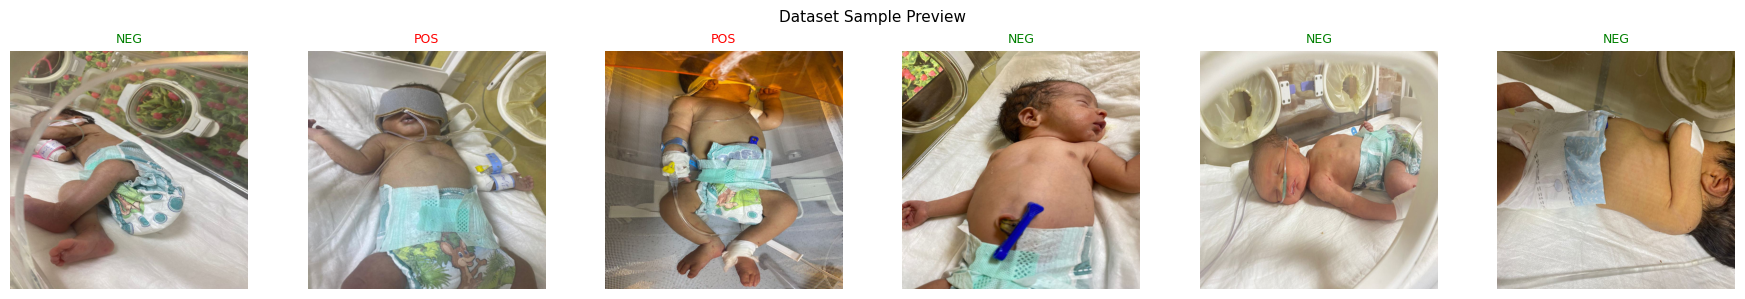

✅ Sample images displayed.


In [6]:
import matplotlib.pyplot as plt, random

n_show = min(6, n_valid)
sample_recs = random.sample(records_ok, n_show)

fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
if n_show == 1: axes = [axes]

for ax, rec in zip(axes, sample_recs):
    img = load_and_validate_image(rec['image_path'])
    img = preprocess_image(img, augment=False)
    ax.imshow(img)
    short = 'POS' if rec['label'] == CFG['pos_response'] else 'NEG'
    ax.set_title(short, fontsize=9,
                 color='red' if short == 'POS' else 'green')
    ax.axis('off')

plt.suptitle('Dataset Sample Preview', fontsize=11)
plt.tight_layout()
plt.show()
print('✅ Sample images displayed.')


## 6 — Train / Val Split

In [7]:
import random
random.seed(CFG['seed'])
random.shuffle(records_ok)

val_size   = max(1, int(len(records_ok) * CFG['val_split']))
val_recs   = records_ok[:val_size]
train_recs = records_ok[val_size:]

print(f'Train samples : {len(train_recs)}')
print(f'Val   samples : {len(val_recs)}')

# ── Label distribution in each split ──────────────────────────────────────────
for split_name, split in [('Train', train_recs), ('Val', val_recs)]:
    n_p = sum(1 for r in split if r['label'] == CFG['pos_response'])
    n_n = sum(1 for r in split if r['label'] == CFG['neg_response'])
    print(f'  {split_name}: {n_p} positive  |  {n_n} negative')

print('\n✅ Split complete.')


Train samples : 684
Val   samples : 76
  Train: 179 positive  |  505 negative
  Val: 21 positive  |  55 negative

✅ Split complete.


## 7 — Load Gemma 4 E4B (4-bit, Unsloth)

In [8]:
from unsloth import FastModel
import torch

print(f'Loading: {CFG["model_name"]} in {"4-bit" if CFG["load_in_4bit"] else "bf16"} ...')
print('First run downloads weights (~9 GB) — may take 5-10 min.')

model, processor = FastModel.from_pretrained(
    model_name     = CFG['model_name'],
    dtype          = None,
    max_seq_length = CFG['max_seq_length'],
    load_in_4bit   = CFG['load_in_4bit'],
)

print('✅ Base model loaded.')
print(f'   dtype  : {next(model.parameters()).dtype}')
print(f'   device : {next(model.parameters()).device}')

if torch.cuda.is_available():
    used  = torch.cuda.memory_allocated() / 1024**3
    total = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'   VRAM   : {used:.2f} GB used / {total:.2f} GB total')


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Loading: unsloth/gemma-4-E4B-it in 4-bit ...
First run downloads weights (~9 GB) — may take 5-10 min.
==((====))==  Unsloth 2026.5.2: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/203 [00:00<?, ?B/s]

processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

✅ Base model loaded.
   dtype  : torch.float16
   device : cuda:0
   VRAM   : 10.22 GB used / 14.56 GB total


In [9]:
model = FastModel.get_peft_model(
    model,
    finetune_vision_layers     = True,
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,
    r                          = CFG['lora_r'],
    lora_alpha                 = CFG['lora_alpha'],
    lora_dropout               = CFG['lora_dropout'],
    bias                       = 'none',
    random_state               = CFG['seed'],
    use_gradient_checkpointing = 'unsloth',
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'✅ LoRA applied — trainable: {trainable:,} / {total:,}  ({100*trainable/total:.2f}%)')


✅ LoRA applied — trainable: 41,222,144 / 6,339,996,192  (0.65%)


## 9 — Baseline Inference (Pre-Training)

Verify the pipeline works before fine-tuning.

In [10]:
import pathlib
FastModel.for_inference(model)

print('── Baseline Inference (pre-training) ────────────────────────')
for label_target in [CFG['pos_response'], CFG['neg_response']]:
    sample = next((r for r in val_recs if r['label'] == label_target), None)
    if sample is None:
        print(f'⚠  No {label_target!r} sample in val set.')
        continue
    try:
        img  = load_and_validate_image(sample['image_path'])
        img  = preprocess_image(img, augment=False)
        pred = run_inference(img)
        match = '✅' if pred == label_target else '❌'
        print(f'{match}  Expected: {label_target!r:20s}  '
              f'Predicted: {pred!r:20s}  '
              f'File: {pathlib.Path(sample["image_path"]).name}')
    except Exception as e:
        print(f'⚠  Error: {e}')

print('\n✅ Baseline inference complete.')
FastModel.for_training(model)


── Baseline Inference (pre-training) ────────────────────────
❌  Expected: 'Jaundice: Yes'       Predicted: "Based on the image provided, it is **not possible to definitively determine if the child has jaundice.**\n\nHere's a breakdown of why:\n\n1."  File: jaundice (170).jpg
❌  Expected: 'Jaundice: No'        Predicted: 'Based on the image provided, it is **not possible to definitively diagnose or rule out jaundice** with certainty.\n\nHere is a detailed analysis:\n\n1.'  File: normal (951).jpg

✅ Baseline inference complete.


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Gemma4ForConditionalGeneration(
      (model): Gemma4Model(
        (language_model): Gemma4TextModel(
          (embed_tokens): Gemma4TextScaledWordEmbedding(262144, 2560, padding_idx=0)
          (layers): ModuleList(
            (0): Gemma4TextDecoderLayer(
              (self_attn): Gemma4TextAttention(
                (q_norm): Gemma4RMSNorm()
                (k_norm): Gemma4RMSNorm()
                (v_norm): Gemma4RMSNorm()
                (k_proj): lora.Linear4bit(
                  (base_layer): Linear4bit(in_features=2560, out_features=512, bias=False)
                  (lora_dropout): ModuleDict(
                    (default): Identity()
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=2560, out_features=16, bias=False)
                  )
                  (lora_B): ModuleDict(
                    (default): Linear(in_features=16, out_features=512, bias

## 10 — Prepare Dataset for SFTTrainer

In [11]:
from datasets import Dataset
from PIL import Image
import random


def make_hf_record(rec: dict, augment: bool = False) -> dict:
    """Convert a record dict into a HuggingFace Dataset row."""
    instruction = random.choice(CFG['instructions'])
    try:
        img = Image.open(rec['image_path']).convert('RGB')
        img = preprocess_image(img, augment=augment)
    except Exception:
        img = Image.new('RGB', (224, 224), color=(200, 200, 200))
    return {
        'messages': [
            {
                'role': 'user',
                'content': [
                    {'type': 'image', 'image': img},
                    {'type': 'text',  'text':  instruction},
                ]
            },
            {
                'role':    'assistant',
                'content': [{'type': 'text', 'text': rec['label']}],
            }
        ]
    }


print('Building training dataset ...')
train_data = [make_hf_record(r, augment=True)  for r in train_recs]
val_data   = [make_hf_record(r, augment=False) for r in val_recs]

train_hf = Dataset.from_list(train_data)
val_hf   = Dataset.from_list(val_data)

print(f'Train HF dataset : {train_hf}')
print(f'Val   HF dataset : {val_hf}')
print('✅ Dataset ready.')


Building training dataset ...
Train HF dataset : Dataset({
    features: ['messages'],
    num_rows: 684
})
Val   HF dataset : Dataset({
    features: ['messages'],
    num_rows: 76
})
✅ Dataset ready.


## 11 — Fine-Tune with SFTTrainer

In [12]:
from unsloth import is_bf16_supported
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig
import torch

# Track VRAM for stats
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    start_gpu_memory = torch.cuda.memory_allocated() / 1024**3
else:
    start_gpu_memory = 0.0

trainer = SFTTrainer(
    model         = model,
    tokenizer     = processor,
    data_collator = UnslothVisionDataCollator(model, processor),
    train_dataset = train_hf,
    args = SFTConfig(
        num_train_epochs            = CFG['num_epochs'],
        max_steps                   = CFG['max_steps'],
        per_device_train_batch_size = CFG['per_device_batch'],
        gradient_accumulation_steps = CFG['grad_accum'],
        learning_rate               = CFG['learning_rate'],
        weight_decay                = CFG['weight_decay'],
        warmup_ratio                = CFG['warmup_ratio'],
        lr_scheduler_type           = CFG['lr_scheduler'],
        fp16                        = not is_bf16_supported(),
        bf16                        = is_bf16_supported(),
        gradient_checkpointing      = True,
        optim                       = 'adamw_8bit',
        logging_steps               = CFG['logging_steps'],
        save_steps                  = CFG['save_steps'],
        output_dir                  = CFG['output_dir'],
        seed                        = CFG['seed'],
        dataset_text_field          = '',
        dataset_kwargs              = {'skip_prepare_dataset': True},
        max_seq_length              = CFG['max_seq_length'],
        remove_unused_columns       = False,
        report_to                   = 'none',
    ),
)

print('✅ Trainer configured.')
total_steps = (
    trainer.args.max_steps
    if trainer.args.max_steps > 0
    else len(trainer.get_train_dataloader()) * CFG['num_epochs']
)
print(f'   Effective total steps : ~{total_steps}')
print('\n🚀 Starting fine-tuning ...')

train_result = trainer.train()
TRAINING_LOGS = trainer.state.log_history

print('\n✅ Fine-tuning complete!')
print(f'   Runtime     : {train_result.metrics.get("train_runtime", 0):.0f}s')
print(f'   Train loss  : {train_result.metrics.get("train_loss", 0):.4f}')
print(f'   Samples/sec : {train_result.metrics.get("train_samples_per_second", 0):.2f}')

if torch.cuda.is_available():
    peak_vram = torch.cuda.max_memory_allocated() / 1024**3
    print(f'   Peak VRAM   : {peak_vram:.2f} GB')


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Model does not have a default image size - using 512


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2}.


✅ Trainer configured.
   Effective total steps : ~684

🚀 Starting fine-tuning ...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 684 | Num Epochs = 1 | Total steps = 171
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 41,222,144 of 8,037,378,592 (0.51% trained)


...

Caching is incompatible with gradient checkpointing in Gemma4TextDecoderLayer. Setting `past_key_values=None`.


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
5,4.057368
10,3.373853
15,1.784656
20,0.636898
25,0.264295
30,0.167970
35,0.121609
40,0.109955
45,0.087943
50,0.072912


Unsloth: Restored added_tokens_decoder metadata in /content/outputs/checkpoint-171/tokenizer_config.json.



✅ Fine-tuning complete!
   Runtime     : 1133s
   Train loss  : 0.3305
   Samples/sec : 0.60
   Peak VRAM   : 11.12 GB


## 12 — Save LoRA Adapters (Backup)

In [13]:
import pathlib, json

lora_dir = CFG['lora_save_path']
pathlib.Path(lora_dir).mkdir(parents=True, exist_ok=True)

print(f'Saving LoRA adapters → {lora_dir} ...')
model.save_pretrained(lora_dir)
processor.save_pretrained(lora_dir)

# Save training logs
with open(f'{lora_dir}/training_logs.json', 'w') as f:
    json.dump(TRAINING_LOGS, f, indent=2)

# Save config (convert sets → lists for JSON)
cfg_s = {k: list(v) if isinstance(v, set) else v for k, v in CFG.items()}
with open(f'{lora_dir}/training_config.json', 'w') as f:
    json.dump(cfg_s, f, indent=2)

print('✅ LoRA adapters saved.')
for fp in sorted(pathlib.Path(lora_dir).rglob('*')):
    if fp.is_file():
        print(f'   {str(fp.relative_to(lora_dir)):50s}  {fp.stat().st_size/1024:>8.1f} KB')


Saving LoRA adapters → /content/jaundice_gemma4_lora ...


Unsloth: Restored added_tokens_decoder metadata in /content/jaundice_gemma4_lora/tokenizer_config.json.


✅ LoRA adapters saved.
   README.md                                                5.1 KB
   adapter_config.json                                      1.6 KB
   adapter_model.safetensors                           161144.9 KB
   chat_template.jinja                                     16.4 KB
   processor_config.json                                    1.6 KB
   tokenizer.json                                       31415.9 KB
   tokenizer_config.json                                    6.7 KB
   training_config.json                                     1.4 KB
   training_logs.json                                       5.9 KB


## 13 — ⚡ Export GGUF & Download (Runs Immediately After Training)

> **Why here?** Colab sessions expire. This cell converts the model to GGUF
> and **triggers the browser download right away**, before you lose the session.

The GGUF file can be used locally with **llama.cpp**, **Ollama**, **LM Studio**, **Jan**, etc.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  GGUF EXPORT — runs automatically. Do NOT skip this cell.
# ══════════════════════════════════════════════════════════════════════════════
import gc, torch, os, pathlib
from google.colab import files as colab_files

gguf_dir    = CFG['gguf_dir']
gguf_method = CFG['gguf_method']       # 'q4_k_m' = ~4 GB, excellent quality

# ── Free VRAM before merge ────────────────────────────────────────────────────
print('🧹 Freeing VRAM before GGUF conversion ...')
gc.collect()
torch.cuda.empty_cache()

if torch.cuda.is_available():
    free = (torch.cuda.get_device_properties(0).total_memory
            - torch.cuda.memory_allocated()) / 1024**3
    print(f'   Free VRAM before conversion: {free:.2f} GB')

# ── Convert + save ────────────────────────────────────────────────────────────
if pathlib.Path(gguf_dir).exists() and \
   list(pathlib.Path(gguf_dir).glob('*.gguf')):
    print(f'✅ GGUF already exists in {gguf_dir}, skipping conversion.')
else:
    print(f'🔀 Converting to GGUF ({gguf_method}) ...')
    print('   This takes 3-8 minutes. Do NOT close the browser tab.')
    model.save_pretrained_gguf(
        gguf_dir,
        processor,
        quantization_method = gguf_method,
    )
    print('✅ GGUF conversion complete.')

# ── Find the .gguf file ───────────────────────────────────────────────────────
gguf_files = list(pathlib.Path(gguf_dir).glob('*.gguf'))
assert gguf_files, f'❌ No .gguf file found in {gguf_dir}'

gguf_file  = str(gguf_files[0])
size_gb    = os.path.getsize(gguf_file) / 1024**3
print()
print('─' * 55)
print(f'  GGUF file : {gguf_file}')
print(f'  Size      : {size_gb:.2f} GB')
print(f'  Method    : {gguf_method}')
print('─' * 55)
print()
print('⬇  Triggering browser download now ...')
colab_files.download(gguf_file)
print('✅ Download triggered. Check your browser downloads folder.')
print()
print('💡 Use with llama.cpp:')
print(f'   ./llama-cli -m {pathlib.Path(gguf_file).name} --mmproj <mmproj.gguf>')
print('   -p "Analyze this medical image for jaundice."')
print()
print('💡 Use with Ollama:')
print(f'   echo \'FROM ./{pathlib.Path(gguf_file).name}\' > Modelfile')
print('   ollama create jaundice-detector -f Modelfile')
print('   ollama run jaundice-detector')


🧹 Freeing VRAM before GGUF conversion ...
   Free VRAM before conversion: 4.10 GB
🔀 Converting to GGUF (q2_k) ...
   This takes 3-8 minutes. Do NOT close the browser tab.
Unsloth: Merging model weights to 16-bit format...


config.json: 0.00B [00:00, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in /content/jaundice_gemma4_gguf/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/16.0G [00:00<?, ?B/s]

### 13b — Export Additional GGUF Sizes (Optional)

Run this cell if you want **smaller** (q2_k, ~2 GB) or **higher quality** (q8_0, ~8 GB) variants.

In [ ]:
# ── Optional: export a second GGUF in a different quantisation ───────────────
# Set EXTRA_METHOD to the quantisation you want, then run this cell.
EXTRA_METHOD = None    # e.g. 'q2_k'  or  'q8_0'  or  'f16'

if EXTRA_METHOD:
    import gc, torch, pathlib
    from google.colab import files as colab_files

    extra_dir = f'/content/baby-gemma{EXTRA_METHOD}'
    print(f'🔀 Converting to GGUF ({EXTRA_METHOD}) → {extra_dir} ...')

    gc.collect()
    torch.cuda.empty_cache()

    model.save_pretrained_gguf(
        extra_dir,
        processor,
        quantization_method = EXTRA_METHOD,
    )

    extra_files = list(pathlib.Path(extra_dir).glob('*.gguf'))
    assert extra_files, 'No .gguf produced'
    extra_file = str(extra_files[0])
    size_gb = os.path.getsize(extra_file) / 1024**3
    print(f'✅ {EXTRA_METHOD} GGUF: {size_gb:.2f} GB')
    print('⬇  Downloading ...')
    colab_files.download(extra_file)
else:
    print('ℹ️  EXTRA_METHOD is None — set it to a quantisation string to export another variant.')


## 14 — Visualise Training Loss

In [ ]:
import matplotlib.pyplot as plt

log_entries = [e for e in TRAINING_LOGS if 'loss' in e]
steps  = [e['step'] for e in log_entries]
losses = [e['loss'] for e in log_entries]

if steps:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(steps, losses, color='royalblue', linewidth=1.5, label='Train Loss')
    ax.set_xlabel('Step')
    ax.set_ylabel('Loss')
    ax.set_title('Training Loss Curve — Gemma 4 E4B Jaundice Detector')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('/content/training_loss.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved → /content/training_loss.png')
else:
    print('⚠️  No training log entries found.')


## 15 — Evaluate (Accuracy / Precision / Recall / F1 / Confusion Matrix)

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib

FastModel.for_inference(model)

y_true, y_pred = [], []
n_eval = len(val_recs)
print(f'Evaluating on {n_eval} validation samples ...')
print('-' * 65)

for i, rec in enumerate(val_recs):
    try:
        img  = load_and_validate_image(rec['image_path'])
        img  = preprocess_image(img, augment=False)
        pred = run_inference(img)
    except Exception as e:
        pred = '__error__'

    tb = 1 if rec['label'] == CFG['pos_response'] else 0
    pb = 1 if pred         == CFG['pos_response'] else 0
    y_true.append(tb)
    y_pred.append(pb)

    match = '✅' if tb == pb else '❌'
    if i < 8 or i >= n_eval - 3:
        print(f'{match} [{i+1:>3}/{n_eval}]  '
              f'True: {rec["label"]:20s}  '
              f'Pred: {pred!r:20s}  '
              f'{pathlib.Path(rec["image_path"]).name}')
    elif i == 8:
        print('          ... (middle results omitted) ...')

# ── Metrics ───────────────────────────────────────────────────────────────────
acc  = accuracy_score(y_true, y_pred)  * 100
prec = precision_score(y_true, y_pred, zero_division=0) * 100
rec  = recall_score(y_true, y_pred,    zero_division=0) * 100
f1   = f1_score(y_true, y_pred,        zero_division=0) * 100

print()
print('=' * 45)
print('  EVALUATION RESULTS')
print('=' * 45)
print(f'  Accuracy  : {acc:6.2f}%')
print(f'  Precision : {prec:6.2f}%')
print(f'  Recall    : {rec:6.2f}%')
print(f'  F1 Score  : {f1:6.2f}%')
print('=' * 45)
print()
print(classification_report(
    y_true, y_pred,
    target_names=['Negative (Normal)', 'Positive (Jaundice)'],
    zero_division=0
))

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm  = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Pred: Normal', 'Pred: Jaundice'],
    yticklabels=['True: Normal', 'True: Jaundice'],
    ax=ax
)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix saved → /content/confusion_matrix.png')


## 16 — Interactive Inference Demo (Upload New Image)

In [ ]:
from google.colab import files as colab_files
import matplotlib.pyplot as plt, pathlib

print('📤 Upload a medical image to classify ...')
uploaded = colab_files.upload()

FastModel.for_inference(model)

for filename, content in uploaded.items():
    tmp = f'/content/{filename}'
    with open(tmp, 'wb') as f: f.write(content)

    try:
        img = load_and_validate_image(tmp)
        img = preprocess_image(img, augment=False)
    except ValueError as e:
        print(f'❌ Cannot load image: {e}'); continue

    pred, conf = run_inference(img, return_confidence=True)
    is_pos = pred == CFG['pos_response']
    emoji  = '🟡' if is_pos else '🟢'

    print()
    print('─' * 50)
    print(f'  PREDICTION  : {emoji}  {pred}')
    print(f'  CONFIDENCE  : {conf:.1f}%')
    print('─' * 50)

    reasoning = (
        'The model detected visual patterns consistent with jaundice '
        '(e.g., yellowing of skin or sclera).'
        if is_pos else
        'No significant jaundice indicators detected. '
        'Appearance is within normal parameters.'
    )
    print(f'  REASONING   : {reasoning}')
    print()

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(img)
    color = 'red' if is_pos else 'green'
    ax.set_title(
        f'{pred}\nConfidence: {conf:.1f}%',
        color=color, fontsize=13, fontweight='bold'
    )
    ax.axis('off')
    plt.tight_layout()
    out_img = f'/content/pred_{pathlib.Path(filename).stem}.png'
    plt.savefig(out_img, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Prediction image saved → {out_img}')


In [ ]:
# ── Post-training predictions on validation samples ───────────────────────────
import matplotlib.pyplot as plt, random
n_show    = min(4, len(val_recs))
show_recs = random.sample(val_recs, n_show)

FastModel.for_inference(model)
fig, axes = plt.subplots(1, n_show, figsize=(4*n_show, 4))
if n_show == 1: axes = [axes]

print('Post-training validation sample predictions:')
for ax, rec in zip(axes, show_recs):
    img  = load_and_validate_image(rec['image_path'])
    img  = preprocess_image(img, augment=False)
    pred, conf = run_inference(img, return_confidence=True)
    match = '✅' if pred == rec['label'] else '❌'
    print(f'{match}  True: {rec["label"]:20s}  '
          f'Pred: {pred:20s}  Conf: {conf:.1f}%')
    ax.imshow(img)
    color = 'green' if pred == rec['label'] else 'red'
    ax.set_title(f'{pred}\n({conf:.0f}%)', fontsize=8, color=color)
    ax.axis('off')

plt.suptitle('Post-Training Val Predictions', fontsize=11)
plt.tight_layout()
plt.show()
print('✅ Done.')


## 17 — Save All Outputs to Google Drive (Optional)

In [ ]:
# Uncomment to save to Google Drive

from google.colab import drive
import shutil, pathlib
drive.mount('/content/drive')

DRIVE_DST = '/content/drive/MyDrive/jaundice_gemma4_outputs'
pathlib.Path(DRIVE_DST).mkdir(parents=True, exist_ok=True)

# Copy LoRA adapters
shutil.copytree(CFG['lora_save_path'], f'{DRIVE_DST}/lora_adapters', dirs_exist_ok=True)

# Copy GGUF
import shutil
for gf in pathlib.Path(CFG['gguf_dir']).glob('*.gguf'):
    shutil.copy2(gf, DRIVE_DST)
    print(f'Copied: {gf.name}')

# Copy plots
for plot in ['/content/training_loss.png', '/content/confusion_matrix.png']:
    if pathlib.Path(plot).exists():
        shutil.copy2(plot, DRIVE_DST)

print(f'✅ All outputs saved to {DRIVE_DST}')
print('ℹ️  Uncomment the lines above and run to save everything to Google Drive.')


## 18 — Use the Downloaded GGUF Locally

### llama.cpp
```bash
# Download & build llama.cpp
git clone https://github.com/ggerganov/llama.cpp && cd llama.cpp
make -j

# Run inference (vision model needs multimodal projector)
./llama-cli -m jaundice-gemma4-q4_k_m.gguf \
    --image /path/to/patient.jpg \
    -p 'Analyze this image for jaundice symptoms.'
```

### Ollama
```bash
printf 'FROM ./jaundice-gemma4-q4_k_m.gguf\n' > Modelfile
ollama create jaundice-detector -f Modelfile
ollama run jaundice-detector
```

### LM Studio / Jan
Drag-and-drop the `.gguf` file into the Models section of LM Studio or Jan.

### Load LoRA with Python (requires base model)
```python
from unsloth import FastModel
from peft import PeftModel

model, processor = FastModel.from_pretrained(
    model_name   = 'unsloth/gemma-4-E4B-it',
    load_in_4bit = True,
)
model = PeftModel.from_pretrained(model, '/path/to/jaundice_gemma4_lora')
FastModel.for_inference(model)
```

## 19 — Run Summary

| Step | Description | Status |
|------|-------------|--------|
| 1 | Install dependencies | Auto |
| 2 | Global configuration | Auto |
| 3 | Download Kaggle dataset (`aiolapo/jaundice-image-data`) | Auto |
| 4 | Image utilities defined | Auto |
| 5 | Scan `jaundice/` + `normal/` folders, validate images | Auto |
| 6 | Train/val split | Auto |
| 7 | Load Gemma 4 E4B (4-bit) | Auto |
| 8 | Apply LoRA | Auto |
| 9 | Baseline inference (pre-training) | Auto |
| 10 | Prepare HF Dataset for SFTTrainer | Auto |
| 11 | Fine-tune with SFTTrainer | Auto |
| 12 | Save LoRA adapters | Auto |
| **13** | **⚡ Export GGUF + trigger download** | **Auto — right after training** |
| 14 | Visualise training loss | Auto |
| 15 | Evaluate (Acc/Prec/Rec/F1/CM) | Auto |
| 16 | Interactive inference demo | Manual (upload image) |
| 17 | Save to Google Drive | Optional |

---

### Dataset structure (Kaggle: `aiolapo/jaundice-image-data`)
```
dataset/
├── jaundice/     → Jaundice: Yes  (positive class)
│   ├── img_001.jpg
│   └── ...
└── normal/       → Jaundice: No   (negative class)
    ├── img_100.jpg
    └── ...
```

### GGUF quantisation guide
| Method | Size | Quality | Best for |
|--------|------|---------|----------|
| `q2_k` | ~2 GB | Low | Very limited VRAM |
| `q4_k_m` | ~4 GB | **Good** ← default | Production use |
| `q8_0` | ~8 GB | Excellent | High-accuracy inference |
| `f16` | ~16 GB | Lossless | Reference / merging |